In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

RAW = "../data/raw/43003099999mumbai.csv"

df = pd.read_csv(RAW, low_memory=False)

print("shape:", df.shape)
print("\ncolumns:")
print(df.columns.tolist())

shape: (19399, 35)

columns:
['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG', 'VIS', 'TMP', 'DEW', 'SLP', 'AA1', 'AY1', 'AY2', 'ED1', 'GA1', 'GA2', 'GA3', 'GA4', 'GE1', 'GF1', 'KA1', 'KA2', 'MA1', 'MD1', 'MW1', 'MW2', 'OC1', 'REM', 'EQD']


In [77]:
#df.head(10)
df[["STATION", "DATE", "REPORT_TYPE", "TMP", "DEW", "SLP"]].head(10)

,STATION,DATE,REPORT_TYPE,TMP,DEW,SLP
0,43003099999,2024-01-01T00:00:00,FM-12,"+0216,1","+0174,1","10120,1"
1,43003099999,2024-01-01T00:00:00,FM-15,"+0240,1","+0180,1","99999,9"
2,43003099999,2024-01-01T00:30:00,FM-15,"+0260,1","+0180,1","99999,9"
3,43003099999,2024-01-01T01:00:00,FM-15,"+0250,1","+0180,1","99999,9"
4,43003099999,2024-01-01T01:30:00,FM-15,"+0250,1","+0180,1","99999,9"
5,43003099999,2024-01-01T02:00:00,FM-15,"+0260,1","+0180,1","99999,9"
6,43003099999,2024-01-01T02:30:00,FM-15,"+0250,1","+0180,1","99999,9"
7,43003099999,2024-01-01T03:00:00,FM-12,"+0222,1","+0191,1","10139,1"
8,43003099999,2024-01-01T03:00:00,FM-15,"+0260,1","+0190,1","99999,9"
9,43003099999,2024-01-01T03:30:00,FM-15,"+0270,1","+0180,1","99999,9"


In [78]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19399 entries, 0 to 19398
Data columns (total 35 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATION          19399 non-null  int64  
 1   DATE             19399 non-null  object 
 2   SOURCE           19399 non-null  int64  
 3   LATITUDE         19399 non-null  float64
 4   LONGITUDE        19399 non-null  float64
 5   ELEVATION        19399 non-null  float64
 6   NAME             19399 non-null  object 
 7   REPORT_TYPE      19399 non-null  object 
 8   CALL_SIGN        19399 non-null  int64  
 9   QUALITY_CONTROL  19399 non-null  object 
 10  WND              19399 non-null  object 
 11  CIG              19399 non-null  object 
 12  VIS              19399 non-null  object 
 13  TMP              19399 non-null  object 
 14  DEW              19399 non-null  object 
 15  SLP              19399 non-null  object 
 16  AA1              753 non-null    object 
 17  AY1         

,STATION,SOURCE,LATITUDE,LONGITUDE,ELEVATION,CALL_SIGN
count,1.939900e+04,19399.0,19399.000000,1.939900e+04,1.939900e+04,19399.0
mean,4.300310e+10,4.0,19.088686,7.286792e+01,1.127000e+01,99999.0
std,0.000000e+00,0.0,0.000000,2.842244e-14,3.552805e-15,0.0
min,4.300310e+10,4.0,19.088686,7.286792e+01,1.127000e+01,99999.0
25%,4.300310e+10,4.0,19.088686,7.286792e+01,1.127000e+01,99999.0
50%,4.300310e+10,4.0,19.088686,7.286792e+01,1.127000e+01,99999.0
75%,4.300310e+10,4.0,19.088686,7.286792e+01,1.127000e+01,99999.0
max,4.300310e+10,4.0,19.088686,7.286792e+01,1.127000e+01,99999.0


In [79]:
def parse_isd(col, missing):
    """Split an ISD 'value,quality' field into a scaled float and its QC code."""
    parts = col.astype(str).str.split(",", expand=True)
    value = pd.to_numeric(parts[0], errors="coerce")
    value = value.where(value != missing) / 10.0
    qc = parts[1]
    return value, qc

d = pd.DataFrame()
d["time"]    = pd.to_datetime(df["DATE"])
d["station"] = df["STATION"].astype(str)
d["report"]  = df["REPORT_TYPE"].astype(str).str.strip()

d["temp_c"],  d["temp_qc"] = parse_isd(df["TMP"], 9999)
d["dew_c"],   d["dew_qc"]  = parse_isd(df["DEW"], 9999)
d["slp_hpa"], d["slp_qc"]  = parse_isd(df["SLP"], 99999)

d.head()

,time,station,report,temp_c,temp_qc,dew_c,dew_qc,slp_hpa,slp_qc
0,2024-01-01 00:00:00,43003099999,FM-12,21.6,1,17.4,1,1012.0,1
1,2024-01-01 00:00:00,43003099999,FM-15,24.0,1,18.0,1,NaN,9
2,2024-01-01 00:30:00,43003099999,FM-15,26.0,1,18.0,1,NaN,9
3,2024-01-01 01:00:00,43003099999,FM-15,25.0,1,18.0,1,NaN,9
4,2024-01-01 01:30:00,43003099999,FM-15,25.0,1,18.0,1,NaN,9


In [80]:
A, B = 17.625, 243.04

d["rh_pct"] = 100 * np.exp(
    (A * d["dew_c"]) / (B + d["dew_c"]) - (A * d["temp_c"]) / (B + d["temp_c"])
)

d["rh_pct"] = d["rh_pct"].clip(upper=100)

print(d[["temp_c", "dew_c", "rh_pct"]].describe())

             temp_c         dew_c        rh_pct
count  19397.000000  19388.000000  19387.000000
mean      28.501614     20.921214     66.554357
std        2.977303      5.325801     18.766699
min       15.400000     -1.000000     10.653746
25%       27.000000     17.000000     53.320073
50%       28.000000     23.000000     70.293061
75%       30.600000     25.000000     83.347810
max       40.000000     29.000000    100.000000


In [81]:
cols = ["temp_c", "slp_hpa", "rh_pct"]

print("rows:", len(d))
print("time range:", d["time"].min(), "→", d["time"].max())
print("station id(s):", d["station"].unique())

print("\n--- missing counts ---")
print(d[cols].isna().sum())

print("\n--- missing percentage ---")
print((d[cols].isna().mean() * 100).round(2))

print("\n--- rows per report type ---")
print(d["report"].value_counts())

print("\n--- temperature quality codes ---")
print(d["temp_qc"].value_counts(dropna=False))

print("\n--- pressure quality codes ---")
print(d["slp_qc"].value_counts(dropna=False))

print("\n--- duplicate timestamps ---")
print(d["time"].duplicated().sum())

rows: 19399
time range: 2024-01-01 00:00:00 → 2024-12-31 23:30:00
station id(s): ['43003099999']

--- missing counts ---
temp_c         2
slp_hpa    16625
rh_pct        12
dtype: int64

--- missing percentage ---
temp_c      0.01
slp_hpa    85.70
rh_pct      0.06
dtype: float64

--- rows per report type ---
report
FM-15    16624
FM-12     2775
Name: count, dtype: int64

--- temperature quality codes ---
temp_qc
1    19353
5       38
2        6
9        2
Name: count, dtype: int64

--- pressure quality codes ---
slp_qc
9    16625
1     2773
2        1
Name: count, dtype: int64

--- duplicate timestamps ---
2703


In [82]:
main_type = d["report"].value_counts().idxmax()
print("most common report type:", main_type)

p = d[d["report"] == main_type].copy()
p = p.sort_values("time").reset_index(drop=True)
p = p.drop_duplicates(subset="time", keep="first").reset_index(drop=True)

p = p[["time", "station", "temp_c", "temp_qc",
       "dew_c", "dew_qc", "slp_hpa", "slp_qc", "rh_pct"]]

print("rows after filtering:", len(p))
print(p.dtypes)
p.head()

most common report type: FM-15
rows after filtering: 16624
time       datetime64[ns]
station            object
temp_c            float64
temp_qc            object
dew_c             float64
dew_qc             object
slp_hpa           float64
slp_qc             object
rh_pct            float64
dtype: object


,time,station,temp_c,temp_qc,dew_c,dew_qc,slp_hpa,slp_qc,rh_pct
0,2024-01-01 00:00:00,43003099999,24.0,1,18.0,1,NaN,9,69.163192
1,2024-01-01 00:30:00,43003099999,26.0,1,18.0,1,NaN,9,61.388520
2,2024-01-01 01:00:00,43003099999,25.0,1,18.0,1,NaN,9,65.145510
3,2024-01-01 01:30:00,43003099999,25.0,1,18.0,1,NaN,9,65.145510
4,2024-01-01 02:00:00,43003099999,26.0,1,18.0,1,NaN,9,61.388520


## Coverage and Gaps


In [83]:
p["gap_hours"] = p["time"].diff().dt.total_seconds() / 3600

print("--- most common intervals (hours) ---")
print(p["gap_hours"].value_counts().head(10))

print("\n--- interval statistics ---")
print(p["gap_hours"].describe())

median_gap = p["gap_hours"].median()
print("\nnominal sampling interval: %.2f hours" % median_gap)

span_hours = (p["time"].max() - p["time"].min()).total_seconds() / 3600
expected = span_hours / median_gap
print("observations present : %d" % len(p))
print("observations expected: %d" % expected)
print("coverage             : %.1f%%" % (100 * len(p) / expected))

gaps = p.loc[p["gap_hours"] > 2 * median_gap, ["time", "gap_hours"]].copy()
gaps["gap_start"] = gaps["time"] - pd.to_timedelta(gaps["gap_hours"], unit="h")
gaps = gaps.rename(columns={"time": "resumed_at"})
print("\n--- missing-data blocks (%d found) ---" % len(gaps))
print(gaps.sort_values("gap_hours", ascending=False).head(15))

--- most common intervals (hours) ---
gap_hours
0.500000    16261
1.000000       84
1.500000       40
0.483333       23
0.466667       18
0.450000       14
0.016667       13
0.033333       13
0.433333       12
0.050000       10
Name: count, dtype: int64

--- interval statistics ---
count    16623.000000
mean         0.528394
std          1.260793
min          0.016667
25%          0.500000
50%          0.500000
75%          0.500000
max        120.500000
Name: gap_hours, dtype: float64

nominal sampling interval: 0.50 hours
observations present : 16624
observations expected: 17567
coverage             : 94.6%

--- missing-data blocks (76 found) ---
               resumed_at  gap_hours           gap_start
4097  2024-04-01 18:00:00      120.5 2024-03-27 17:30:00
14799 2024-11-21 22:00:00       96.5 2024-11-17 21:30:00
10217 2024-08-12 22:00:00       25.5 2024-08-11 20:30:00
5428  2024-05-01 22:00:00       24.5 2024-04-30 21:30:00
15224 2024-12-01 22:00:00       24.5 2024-11-30 21:30:00
4

In [84]:
frac = p["temp_c"].dropna().mod(1)
print("fractional parts of temperature values:")
print(frac.value_counts().head(10))
print("\ndistinct temperature values:", p["temp_c"].nunique())

fractional parts of temperature values:
temp_c
0.0    16623
Name: count, dtype: int64

distinct temperature values: 21


In [85]:
tenths = (p["temp_c"].dropna() * 10).round().mod(10)
print(tenths.value_counts())

temp_c
0.0    16623
Name: count, dtype: int64


In [86]:
def timeplot(x, y, title, ylabel, color, outfile):
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.plot(x, y, lw=0.5, color=color)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Date (UTC)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    fig.autofmt_xdate(rotation=45)

    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()

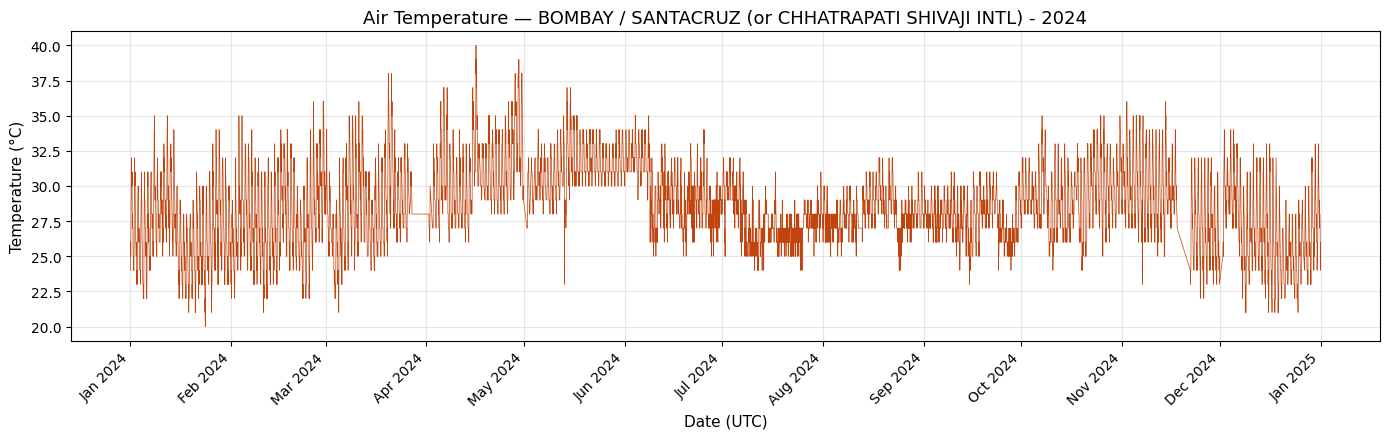

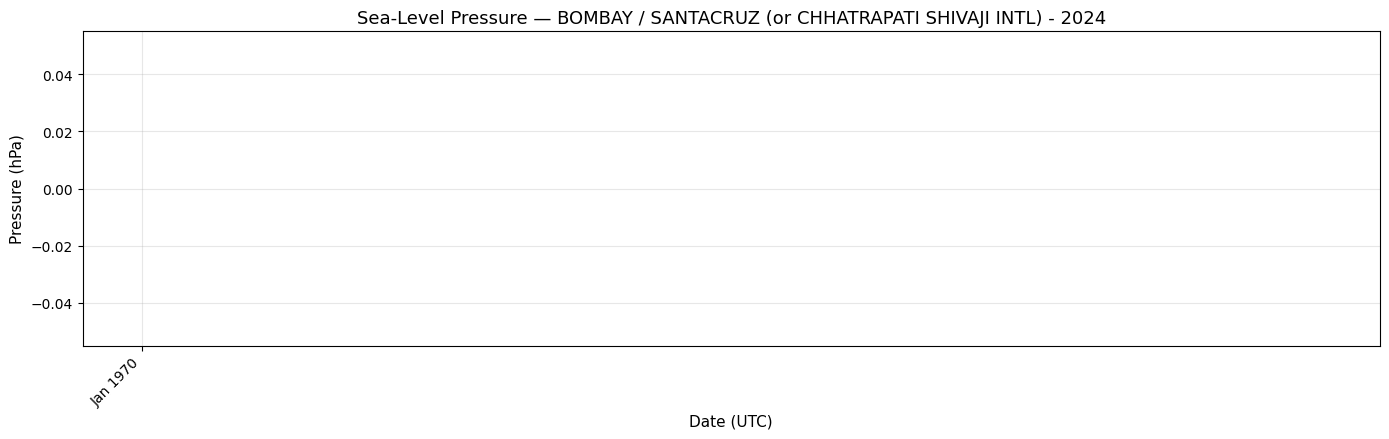

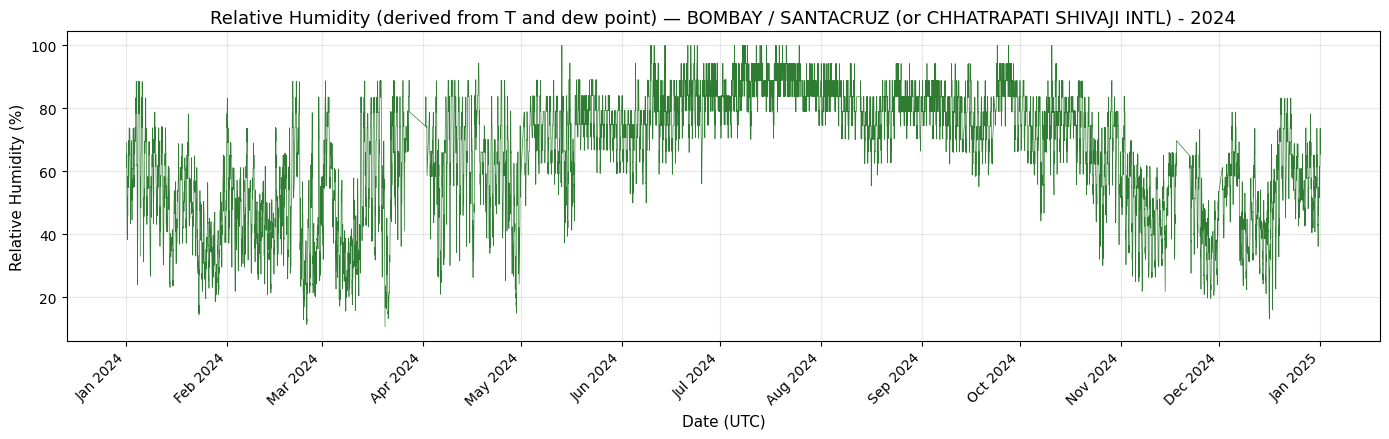

In [87]:
STATION_LABEL = "BOMBAY / SANTACRUZ (or CHHATRAPATI SHIVAJI INTL) - 2024"

timeplot(p["time"], p["temp_c"],
         "Air Temperature — " + STATION_LABEL,
         "Temperature (°C)", "#c1440e",
         "../figures/01_temperature_mumbai.png")

timeplot(p["time"], p["slp_hpa"],
         "Sea-Level Pressure — " + STATION_LABEL,
         "Pressure (hPa)", "#1f4e79",
         "../figures/02_pressure_mumbai.png")

timeplot(p["time"], p["rh_pct"],
         "Relative Humidity (derived from T and dew point) — " + STATION_LABEL,
         "Relative Humidity (%)", "#2e7d32",
         "../figures/03_humidity_mumbai.png")

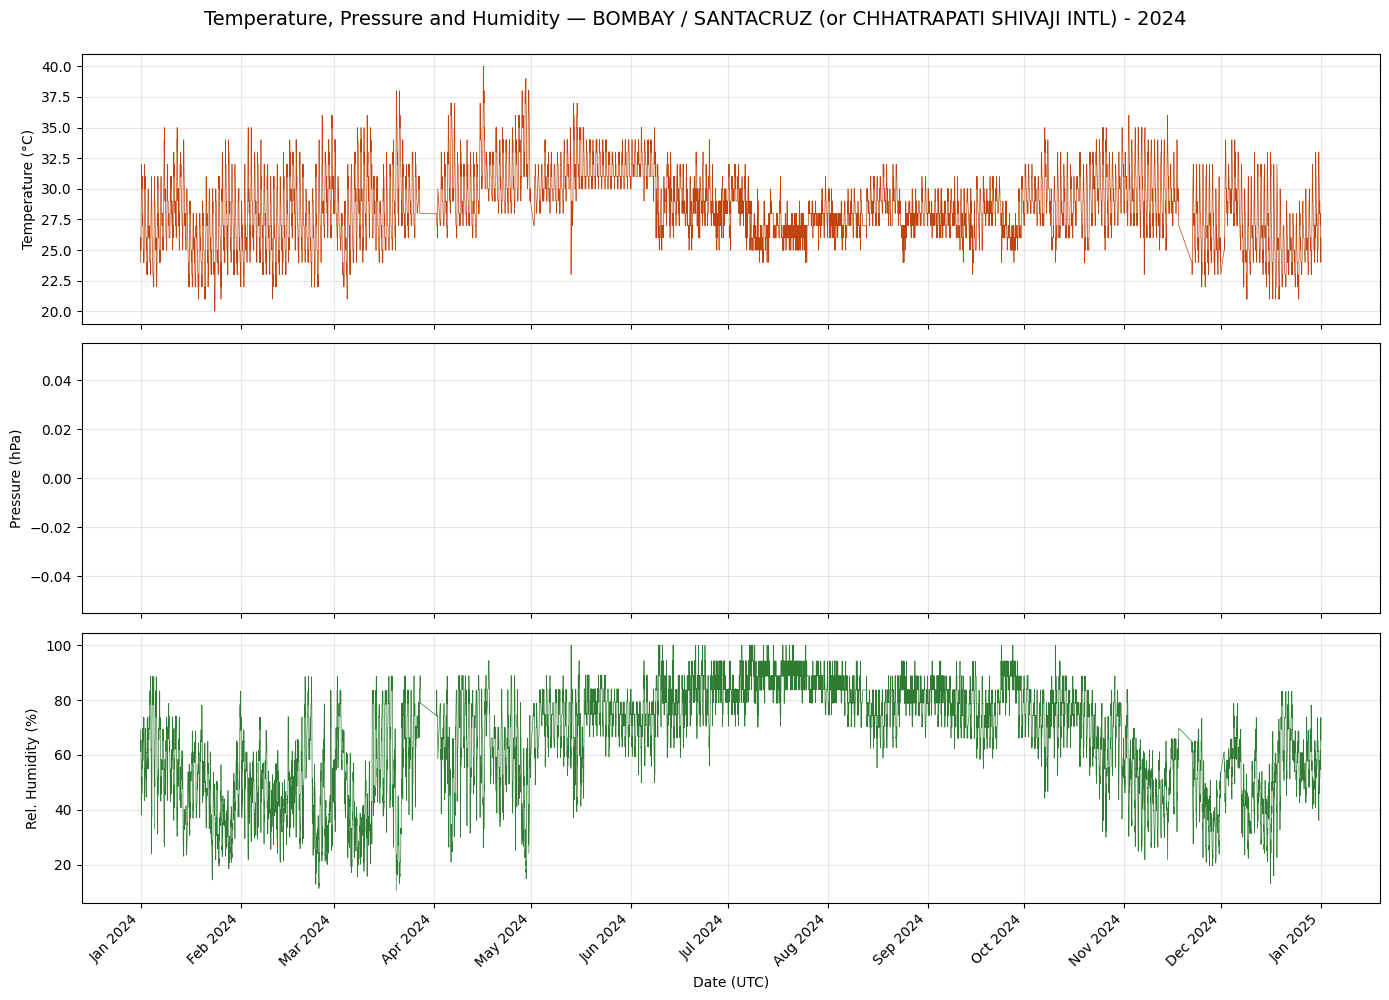

In [88]:
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax[0].plot(p["time"], p["temp_c"], lw=0.5, color="#c1440e")
ax[0].set_ylabel("Temperature (°C)")
ax[0].grid(alpha=0.3)

ax[1].plot(p["time"], p["slp_hpa"], lw=0.5, color="#1f4e79")
ax[1].set_ylabel("Pressure (hPa)")
ax[1].grid(alpha=0.3)

ax[2].plot(p["time"], p["rh_pct"], lw=0.5, color="#2e7d32")
ax[2].set_ylabel("Rel. Humidity (%)")
ax[2].set_xlabel("Date (UTC)")
ax[2].grid(alpha=0.3)

ax[2].xaxis.set_major_locator(mdates.MonthLocator())
ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(rotation=45)

fig.suptitle("Temperature, Pressure and Humidity — " + STATION_LABEL,
             fontsize=14, y=0.995)
fig.tight_layout()
fig.savefig("../figures/04_combined_mumbai.png", dpi=150, bbox_inches="tight")
plt.show()

In [89]:
cols = ["temp_c", "slp_hpa", "rh_pct"]

stats = p[cols].agg(["min", "max", "mean", "median", "std"]).T.round(2)
stats["missing_pct"] = (p[cols].isna().mean() * 100).round(2)
stats["n_valid"] = p[cols].notna().sum()

print(stats)
stats.to_csv("../data/processed/summary_stats_mumbai.csv")

           min    max   mean  median    std  missing_pct  n_valid
temp_c   20.00   40.0  28.57   28.00   2.79         0.01    16623
slp_hpa    NaN    NaN    NaN     NaN    NaN       100.00        0
rh_pct   10.65  100.0  65.77   70.11  18.94         0.03    16619


c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [90]:
for c, label in [("temp_c", "Temperature"), ("slp_hpa", "Pressure"), ("rh_pct", "Humidity")]:
    p[c + "_step"] = p[c].diff()

    print("\n=== %s: 10 largest changes between consecutive readings ===" % label)
    top = p.reindex(p[c + "_step"].abs().sort_values(ascending=False).index).head(10)
    print(top[["time", c, c + "_step", "gap_hours"]].to_string(index=False))


=== Temperature: 10 largest changes between consecutive readings ===
               time  temp_c  temp_c_step  gap_hours
2024-11-07 05:00:00    31.0          8.0        0.5
2024-05-13 11:30:00    23.0         -7.0        0.5
2024-11-07 04:30:00    23.0         -6.0        0.5
2024-12-18 14:00:00    26.0         -6.0        6.0
2024-10-10 16:00:00    24.0         -5.0        0.5
2024-07-10 08:00:00    25.0         -5.0        1.0
2024-06-08 19:30:00    26.0         -5.0        0.5
2024-06-13 04:00:00    26.0         -5.0        0.5
2024-06-10 14:30:00    25.0         -5.0        0.5
2024-02-26 13:30:00    29.0         -4.0        3.5

=== Pressure: 10 largest changes between consecutive readings ===
               time  slp_hpa  slp_hpa_step  gap_hours
2024-01-01 00:00:00      NaN           NaN        NaN
2024-01-01 00:30:00      NaN           NaN        0.5
2024-01-01 01:00:00      NaN           NaN        0.5
2024-01-01 01:30:00      NaN           NaN        0.5
2024-01-01 02:00:00  

In [91]:
def find_flat_runs(frame, col, min_len=8):
    s = frame[col]
    run_id = s.ne(s.shift()).cumsum()
    g = frame.assign(_run=run_id).groupby("_run")
    runs = g.agg(start=("time", "min"),
                 end=("time", "max"),
                 length=("time", "size"),
                 value=(col, "first"))
    runs = runs[(runs["length"] >= min_len) & runs["value"].notna()]
    return runs.sort_values("length", ascending=False)

for c, label in [("temp_c", "Temperature"), ("slp_hpa", "Pressure"), ("rh_pct", "Humidity")]:
    r = find_flat_runs(p, c, min_len=8)
    print("\n=== %s: constant runs of 8+ consecutive readings (%d found) ===" % (label, len(r)))
    print(r.head(10).to_string())


=== Temperature: constant runs of 8+ consecutive readings (336 found) ===
                   start                 end  length  value
_run                                                       
3292 2024-07-03 13:30:00 2024-07-04 02:30:00      27   29.0
2769 2024-06-02 14:30:00 2024-06-03 01:30:00      23   31.0
4525 2024-09-21 14:00:00 2024-09-22 01:00:00      23   28.0
3703 2024-07-26 10:30:00 2024-07-26 21:30:00      23   28.0
4048 2024-08-20 15:00:00 2024-08-21 02:30:00      23   27.0
3385 2024-07-08 15:30:00 2024-07-09 02:00:00      22   25.0
2819 2024-06-06 16:30:00 2024-06-07 02:30:00      22   31.0
2827 2024-06-07 13:30:00 2024-06-07 23:30:00      21   31.0
2706 2024-05-27 10:00:00 2024-05-27 20:30:00      21   31.0
4084 2024-08-23 13:30:00 2024-08-23 22:30:00      19   27.0

=== Pressure: constant runs of 8+ consecutive readings (0 found) ===
Empty DataFrame
Columns: [start, end, length, value]
Index: []

=== Humidity: constant runs of 8+ consecutive readings (132 found) ===


In [92]:
candidates = []

for c in cols:
    r = find_flat_runs(p, c, min_len=8)
    for _, row in r.head(5).iterrows():
        candidates.append({"variable": c, "type": "flat_run",
                           "start": row["start"], "end": row["end"],
                           "detail": "%d constant readings at %.1f" % (row["length"], row["value"])})

for _, row in gaps.sort_values("gap_hours", ascending=False).head(5).iterrows():
    candidates.append({"variable": "all", "type": "missing_block",
                       "start": row["gap_start"], "end": row["resumed_at"],
                       "detail": "%.1f hour gap" % row["gap_hours"]})

for c in cols:
    top = p.reindex(p[c + "_step"].abs().sort_values(ascending=False).index).head(3)
    for _, row in top.iterrows():
        candidates.append({"variable": c, "type": "step",
                           "start": row["time"], "end": row["time"],
                           "detail": "change of %.1f in %.1f h" % (row[c + "_step"], row["gap_hours"])})

cand = pd.DataFrame(candidates).sort_values("start").reset_index(drop=True)
cand.to_csv("../data/processed/candidate_periods_mumbai.csv", index=False)
print(cand.to_string())

   variable           type               start                 end                        detail
0   slp_hpa           step 2024-01-01 00:00:00 2024-01-01 00:00:00        change of nan in nan h
1   slp_hpa           step 2024-01-01 00:30:00 2024-01-01 00:30:00        change of nan in 0.5 h
2   slp_hpa           step 2024-01-01 01:00:00 2024-01-01 01:00:00        change of nan in 0.5 h
3    rh_pct           step 2024-02-26 13:30:00 2024-02-26 13:30:00       change of 36.0 in 3.5 h
4       all  missing_block 2024-03-27 17:30:00 2024-04-01 18:00:00                120.5 hour gap
5       all  missing_block 2024-04-30 21:30:00 2024-05-01 22:00:00                 24.5 hour gap
6    rh_pct           step 2024-05-13 11:30:00 2024-05-13 11:30:00       change of 44.9 in 0.5 h
7    temp_c           step 2024-05-13 11:30:00 2024-05-13 11:30:00       change of -7.0 in 0.5 h
8    rh_pct       flat_run 2024-05-23 13:00:00 2024-05-23 21:00:00  17 constant readings at 84.1
9    rh_pct       flat_run 202

In [93]:
p.to_csv("../data/processed/vidd_2023_clean_mumbai.csv", index=False)
print("saved", len(p), "rows")
print(p.columns.tolist())

saved 16624 rows
['time', 'station', 'temp_c', 'temp_qc', 'dew_c', 'dew_qc', 'slp_hpa', 'slp_qc', 'rh_pct', 'gap_hours', 'temp_c_step', 'slp_hpa_step', 'rh_pct_step']
